In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("../XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

plt.rcParams.update({'font.size': 14})

# Experiment parameters
X-ray energy: 9.83 keV
Diamond grating groove depth: 4 um
Diamond grating substrate: 30um - 4um = 26 um

Gold grating groove depth: 1.9 um
Gold grating substrate: 250 nm SiN

Silicon grating groove depth: 8 um
Silicon grating substrate: 25um - 8um = 17 um

In [8]:
# Get the incident wave-vector
E_c = 11.0
waveveclength = util.kev_to_wavevec_length(energy=E_c)


def getGratings(tilt_angle):
    # Create each grating object
    diaGrat = Crystal.RectangleGrating(a=0.5,
                                       b=0.5,
                                       n=1.-0.60334E-05+ 0.41231E-08 * 1.0j ,
                                       height=4 / np.cos(tilt_angle),
                                       base_thickness=26. / np.cos(tilt_angle))

    siliGrat = Crystal.RectangleGrating(a=0.25,
                                        b=0.25,
                                        n=1. - 0.50532 * 1e-5 + 1.j * 0.79565 * 1e-7,
                                        height=8 / np.cos(tilt_angle),
                                        base_thickness=17. / np.cos(tilt_angle))

    goldGrat = Crystal.RectangleGrating(a=0.25,
                                        b=0.25,
                                        n=1. - 0.18584E-04  + 1.j * 0.22432E-05,
                                        height=1. / np.cos(tilt_angle),
                                        base_thickness=1e-6 / np.cos(tilt_angle))

    SiNsubstrate = Crystal.RectangleGrating(a=10000,
                                            b=10000,
                                            n=1. - 0.50532 * 1e-5 + 1.j * 0.79565 * 1e-7,
                                            # I cannot find the value for SiN. Therefore, I use the value from Si 
                                            height=1e-6 / np.cos(tilt_angle),
                                            base_thickness=0.25 / np.cos(tilt_angle))

    return diaGrat, siliGrat, goldGrat, SiNsubstrate


# Loop through the angles
angle_list = np.linspace(start=-np.deg2rad(10), stop=np.deg2rad(70), num=100)
diamondEfficiencies_1st = np.zeros_like(angle_list)
siliconEfficiencies_1st = np.zeros_like(angle_list)
goldEfficiencies_1st = np.zeros_like(angle_list)

diamondEfficiencies_0th = np.zeros_like(angle_list)
siliconEfficiencies_0th = np.zeros_like(angle_list)
goldEfficiencies_0th = np.zeros_like(angle_list)

for angle_idx in range(angle_list.shape[0]):
    angle = angle_list[angle_idx]
    wavevec = np.array([0, 0, 1.]) * waveveclength
    myDiamondGrating, mySiliconGrating, myGoldGrating, mySiNsubstrate = getGratings(tilt_angle=angle)

    # Get efficiency from diamond grating
    diamondEfficiencies_0th[angle_idx] = np.abs(myDiamondGrating.get_grating_coefficient(kin=wavevec, order=0)) ** 2
    diamondEfficiencies_1st[angle_idx] = np.abs(myDiamondGrating.get_grating_coefficient(kin=wavevec, order=1)) ** 2

    # Get efficiency from diamond grating
    siliconEfficiencies_0th[angle_idx] = np.abs(mySiliconGrating.get_grating_coefficient(kin=wavevec, order=0)) ** 2
    siliconEfficiencies_1st[angle_idx] = np.abs(mySiliconGrating.get_grating_coefficient(kin=wavevec, order=1)) ** 2

    # Get efficiency from diamond grating
    tmp = np.abs(mySiNsubstrate.get_grating_coefficient(kin=wavevec, order=0)) ** 2
    goldEfficiencies_0th[angle_idx] = (np.abs(myGoldGrating.get_grating_coefficient(kin=wavevec, order=0)) ** 2) * tmp
    goldEfficiencies_1st[angle_idx] = (np.abs(myGoldGrating.get_grating_coefficient(kin=wavevec, order=1)) ** 2) * tmp
    #print(tmp)

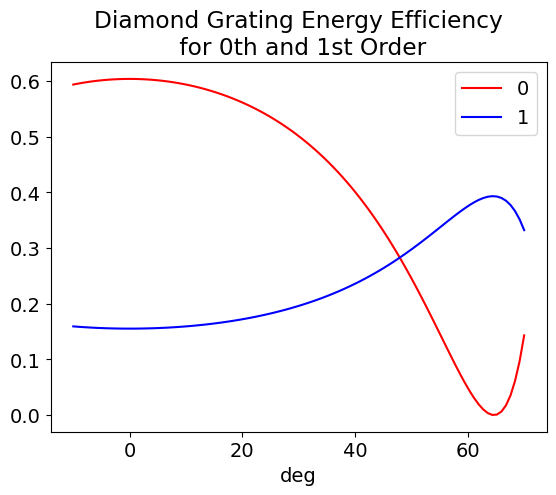

In [9]:
plt.plot(np.rad2deg(angle_list), diamondEfficiencies_0th, label='0', c='r')
plt.plot(np.rad2deg(angle_list), diamondEfficiencies_1st, label='1', c='b')
plt.legend()
plt.xlabel("deg")
plt.title("Diamond Grating Energy Efficiency\n for 0th and 1st Order")
plt.show()

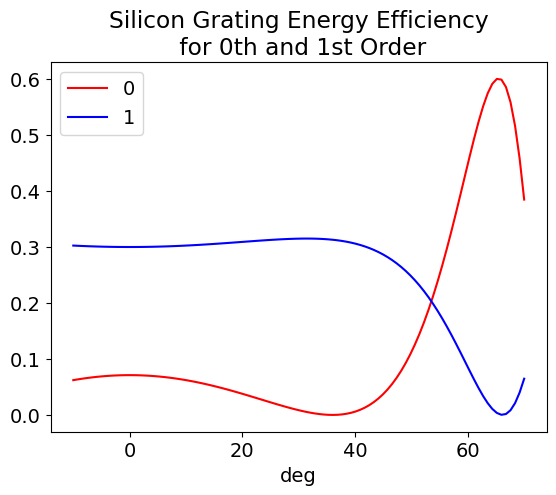

In [6]:
plt.plot(np.rad2deg(angle_list), siliconEfficiencies_0th, label='0', c='r')
plt.plot(np.rad2deg(angle_list), siliconEfficiencies_1st, label='1', c='b')
plt.legend()
plt.xlabel("deg")
plt.title("Silicon Grating Energy Efficiency\n for 0th and 1st Order")
plt.show()

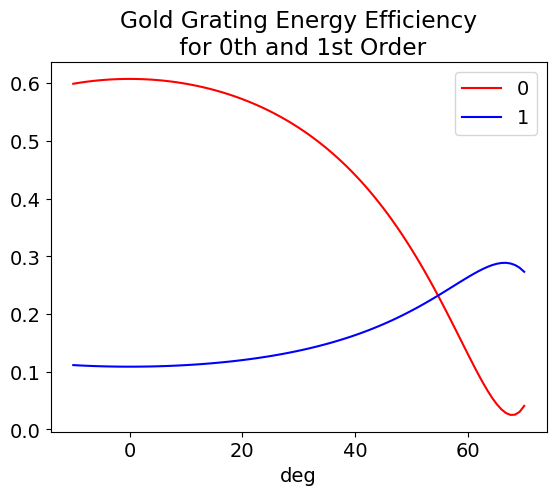

In [7]:
plt.show()
plt.plot(np.rad2deg(angle_list), goldEfficiencies_0th, label='0', c='r')
plt.plot(np.rad2deg(angle_list), goldEfficiencies_1st, label='1', c='b')
plt.legend()
plt.xlabel("deg")
plt.title("Gold Grating Energy Efficiency\n for 0th and 1st Order")
plt.show()

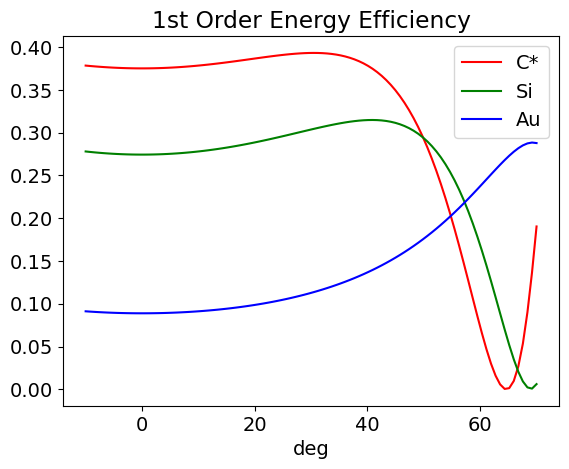

In [7]:
plt.show()
plt.plot(np.rad2deg(angle_list), diamondEfficiencies_1st, label='C*', c='r')
plt.plot(np.rad2deg(angle_list), siliconEfficiencies_1st, label='Si', c='g')
plt.plot(np.rad2deg(angle_list), goldEfficiencies_1st, label='Au', c='b')
plt.legend()
plt.xlabel("deg")
plt.title("1st Order Energy Efficiency")
plt.show()

In [9]:
goldEfficiencies_1st / goldEfficiencies_0th

array([ 0.18563328,  0.1845121 ,  0.18349398,  0.18257656,  0.18175774,
        0.18103566,  0.18040868,  0.1798754 ,  0.17943463,  0.17908539,
        0.17882692,  0.17865865,  0.1785802 ,  0.1785914 ,  0.17869229,
        0.17888307,  0.17916417,  0.1795362 ,  0.18      ,  0.18055659,
        0.1812072 ,  0.18195331,  0.1827966 ,  0.18373898,  0.18478263,
        0.18592997,  0.1871837 ,  0.18854679,  0.19002251,  0.19161448,
        0.19332662,  0.19516324,  0.19712903,  0.19922911,  0.20146902,
        0.20385482,  0.20639309,  0.20909095,  0.21195617,  0.2149972 ,
        0.21822319,  0.22164414,  0.22527091,  0.22911533,  0.23319031,
        0.23750993,  0.2420896 ,  0.24694616,  0.25209807,  0.25756557,
        0.26337092,  0.26953861,  0.27609567,  0.28307193,  0.29050045,
        0.29841788,  0.306865  ,  0.31588725,  0.32553541,  0.3358664 ,
        0.34694415,  0.35884073,  0.37163761,  0.38542724,  0.40031484,
        0.41642066,  0.43388267,  0.45285981,  0.47353604,  0.49

In [10]:
78 - 12.5

65.5

In [11]:
40 - (254 - 12.7 - 224)

22.69999999999999

In [12]:
3.5 * 6.5 / 10

2.275

In [13]:
import numpy as np

In [14]:
theta1 = np.deg2rad(11.6)
theta2 = np.deg2rad(30)
theta3 = 0. #theta1 # np.deg2rad(30)

vec1 = np.array([0,0,1])
vec2 = np.array([0,-np.sin(2*theta1),np.cos(2*theta1)])
vec3 = np.array([np.cos(theta2),np.sin(theta2) * np.sin(theta3), - np.sin(theta2)* np.cos(theta3)])

In [15]:
np.rad2deg(np.arcsin(np.dot(vec2, vec3))) - np.rad2deg(np.arcsin(np.dot(vec1, vec3))) 

2.6407864670086916

In [16]:
angle = np.deg2rad(np.linspace(-50, 50, 100))
res = np.zeros(100)
res2 = np.zeros(100)
for idx in range(100):
    vec3 = np.array([np.cos(theta2),np.sin(theta2) * np.sin(angle[idx]),-np.sin(theta2)* np.cos(angle[idx])])
    res[idx] = np.rad2deg(np.arcsin(np.dot(vec2, vec3)))
    res2[idx] = np.rad2deg(np.arcsin(np.dot(vec1, vec3)))


In [17]:
import matplotlib.pyplot as plt

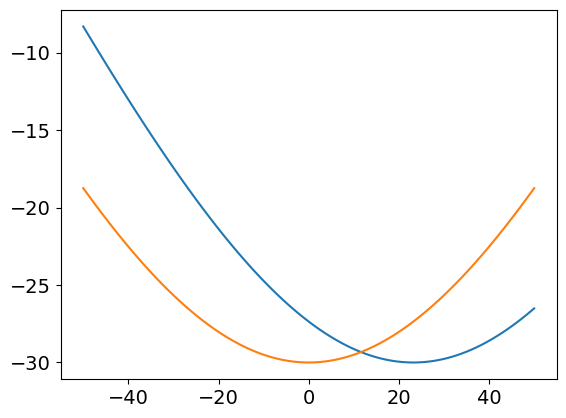

In [18]:
plt.plot(np.rad2deg(angle), res)
plt.plot(np.rad2deg(angle), res2)

plt.show()

In [19]:
plt.plot(np.rad2deg(angle), diff)
plt.show()

NameError: name 'diff' is not defined

In [ ]:
    diff = np.abs(res - res2)
tmp = np.argmin(diff)

In [ ]:
np.rad2deg(angle[tmp])

In [ ]:
import numpy as np

In [ ]:
6 * np.sqrt(2) - 6

In [27]:
Icr = 1.054571817e-34 ** 3 * 2.3696e+18 / 9.1e-31 / (1.6e-19) ** 2 / (5e-11) ** 4
print(Icr)

1.9087196680057211e+25


In [28]:
Icr = (1.054571817 * 2.3696 / 9.1 / (1.6) ** 2 / (5) ** 4) * 10 ** (-34 * 3 + 18 + 31 + 19 * 2 + 11 * 4)


In [29]:
Icr

1.7162866604142855e+25

In [37]:
Energy = 10 * 0.4 * 0.8 * 0.4 * 1e-6 # pump energy
beamsize = (30e-6) ** 2
duration = 10e-15 

power = Energy / duration
intensity = power / beamsize
print("{:.2e}".format(power), "W")
print("{:.2e}".format(intensity / 1e4), "W/cm^2")

1.28e+08 W
1.42e+13 W/cm^2


In [36]:
Energy

1.2800000000000002e-06